In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
class Value:

    def __init__(self, data, _children=(), _op='', label = ''):
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    # addition
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)     # makes operations like a + 1 work because it converts 1 to a value object with a data attribute
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
             self.grad += 1.0 * out.grad        # must use += to accumulate the gradients; otherwise, 2 neurons ahead of it, both accessing it, will overwrite each other's gradients they deposit
             other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    # multiplication
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)     # makes operations like a + 1 work because it converts 1 to a value object with a data attribute
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        
        out._backward = _backward
        return out

    

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad


        out._backward = _backward

        return out


    def __radd__(self, other):
        return self + other


    # reverse multiplication (makes 2 * a work)
    def __rmul__(self, other): # other * self
        return self * other



    # division
    def __truediv__(self, other): # self / other
        return self * other**-1


    # negation / negative values
    def __neg__(self): # -self
        return self * -1
    
    # subtraction
    def __sub__(self, other): # self - other
        return self + (-other)



    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        # it plugs its specific _backward function into the output's previously blank one. When the out runs _backward, it actually triggers the _backward function inside self.
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        return out

    

    def backward(self):

        # initialize empty graph
        topo = []

        # make a set for visited nodes
        visited = set()

        def build_topo(v):
            
            # how to delete from end of line to right after a certain character in the line

            if v not in visited:
                visited.add(v)

                # recursively call function to add children first, creating the array sorted so that the first nodes are on the left and the final node is on the very right
                for child in v._prev:
                    build_topo(child)
                
                # add self after all children are added
                topo.append(v)
            
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()




In [9]:
a = Value(2.0)
b = Value(4.0)
a - b

Value(data=-2.0)

In [10]:
from graphviz import Digraph

# root is the argument. In this case, it's d
def trace(root):

    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    # v is a Value object that we defined above!
    def build(v):
        
        if v not in nodes:
            nodes.add(v)

            for child in v._prev:

                # add a tuple of (child, v) to the edges array (add an edge from the child to the v (result) node)
                edges.add((child, v))

                # recursively build each child (and their children) as its own node
                build(child)            

    build(root)
    return nodes, edges

def draw_dot(root):
    
    # create a graph named dot
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = Left to Right

    # run trace to generate nodes and edges tuples
    nodes, edges = trace(root)


    for n in nodes:

        # create a unique id for each node
        uid = str(id(n))

        # for any value in the graph, create a rectangluar ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')

        # if this value is the result of some operation, create an op node for it
        if n._op:
            dot.node(name = uid + n._op, label = n._op)

            # and connect this node to it. Edge follows left-> right because of the argument we passed to graph creation earlier
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2. The first execution of this is creating an edge between c's node and d's operation.
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot



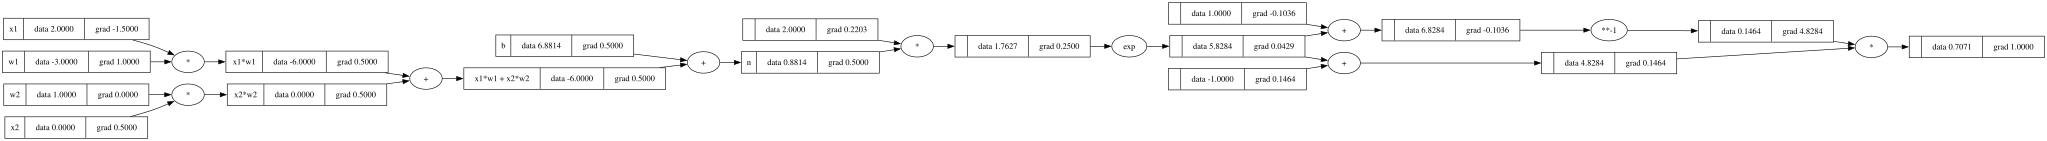

In [13]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e-1) / (e + 1)
# ----
o.backward()
draw_dot(o)

In [14]:
import torch

In [15]:
x1 = torch.tensor([2.0], dtype=torch.double, requires_grad=True)
x2 = torch.tensor([0.0], dtype=torch.double, requires_grad = True)
w1 = torch.tensor([-3.0], dtype=torch.double, requires_grad = True) 
w2 = torch.tensor([1.0], dtype=torch.double, requires_grad = True)
b = torch.tensor([6.8813735870195432], dtype=torch.double, requires_grad = True)

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071067811865476
---
x2 0.49999999999999994
w2 0.0
x1 -1.4999999999999998
w1 0.9999999999999999


In [16]:
import random

In [17]:
a = Value(2.0)
b = 3 + a
b

Value(data=5.0)

In [18]:
class Neuron:

    def __init__(self, nin): # stands for number of inputs
        
        # initialize a weight for each input and store it in an array
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        
        # initialize a universal bias for the neuron
        self.b = Value(random.uniform(-1, 1))

     
    def __call__(self, x): # gets called whenever n() is called
        
        # gives us the activation function input. We multiply the weights and values of the inputs together, then sum them up and add the bias on top
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)

        # actual activation function: tanh
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

    
class Layer:

    def __init__(self, nin, nout): # nout is used to define the number of neurons in the layer; number of outputs (because each neuron has 1 output)
        
        # initializes an array of neurons given the desired amount (nout)
        self.neurons = [Neuron(nin) for _ in range (nout)]


    def __call__(self, x):

        # calls n(x) for each neuron given the x array (its __call__ function), computing the final output for each neuron, then stores the outputs in a list
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        


class MLP:

    def __init__(self, nin, nouts): # nouts is a list of nout(s): defines the sizes of all the layers in our net. Here, nin only represents the number of inputs to the network.
        
        # adds the number of inputs to the network to the beginning of nouts, essentially creating a list with all inputs in the network
        sz = [nin] + nouts
        
        # creates a list of Layer objects with each one having an input equal to the previous layer's output
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):

        # initializes each layer with x as the input (uses the Layer class __call__ function)
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]



In [19]:
# inputs
x = [2.0, 3.0, -1.0]

# passes number of ins to the network, and defines 3 layers with 4 neurons each. The neurons initialize with random biases and weights.
n = MLP(3, [4, 4, 1])

# the MLP is then called with the inputs, which then call the layers with the inputs sequentially
n(x)


Value(data=-0.34153254481016965)

In [20]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # desired targets


In [21]:

for k in range(20):

    # forward pass
    ypred = [n(x) for x in xs] # call the MLP using the xs we just defined
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters(): # reset gradient of each parameter to 0 so gradients don't get infinitely added
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad
    
    print(k, loss.data)

0 3.6524304380332353
1 1.1733074346228893
2 0.7102979641696221
3 0.47702394224451516
4 0.34433379357289584
5 0.2635306237038978
6 0.2107238225919502
7 0.17412094567172334
8 0.14753137938023425
9 0.12748021861430453
10 0.11189690391489515
11 0.09948332451309139
12 0.0893899746526382
13 0.08104036443311365
14 0.07403097443556388
15 0.06807173630959418
16 0.06294926524145111
17 0.0585033872367516
18 0.05461171399141544
19 0.05117924351828967


In [23]:
ypred

[Value(data=0.8989318434791188),
 Value(data=-0.9477518100116313),
 Value(data=-0.8561714849808505),
 Value(data=0.8675313011836912)]